In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

### Function 8: High-dimensional Optimisation

You’ve reach the final, 8-dimensional search space. High-dimensional black-box optimisation can be very difficult, so sticking to local solutions is not the worst idea here.


### Data Loading and Preprocessing

The following code cell loads the initial input and output data for the contamination source search problem. It also appends additional queries and observations from external files i.e. queries.txt and observations.txt, ensuring that the dataset is comprehensive and ready for further analysis and modeling.

In [2]:
import ast
import numpy as np

def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = ast.literal_eval(formatted_query)  # Use ast.literal_eval for safety
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
         0.57533801, 0.31031095, 0.73428138],
        [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
         0.70790879, 0.63538449, 0.10713163],
        [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
         0.09165169, 0.59241515, 0.36732026],
        [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.0937283 ,
         0.19742533, 0.7558269 , 0.29247234],
        [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
         0.28920692, 0.55729515, 0.59388173],
        [0.77881834, 0.0034195 , 0.33798313, 0.51952778, 0.82090699,
         0.53724669, 0.5513471 , 0.66003209],
        [0.90864932, 0.0622497 , 0.23825955, 0.76660355, 0.13233596,
         0.99024381, 0.68806782, 0.74249594],
        [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
         0.74899176, 0.23090707, 0.09791562],
        [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
         0.

In [4]:
queries = queries_for_function(8)
X = np.vstack([X, queries])
X, len(X)

(array([[6.04994453e-01, 2.92215020e-01, 9.08452748e-01, 3.55506242e-01,
         2.01668719e-01, 5.75338005e-01, 3.10310951e-01, 7.34281377e-01],
        [1.78006959e-01, 5.66222654e-01, 9.94861845e-01, 2.10325006e-01,
         3.20152657e-01, 7.07908792e-01, 6.35384489e-01, 1.07131627e-01],
        [9.07697668e-03, 8.11626153e-01, 5.20520360e-01, 7.56866752e-02,
         2.65111825e-01, 9.16516894e-02, 5.92415145e-01, 3.67320262e-01],
        [5.06028164e-01, 6.53730123e-01, 3.63410779e-01, 1.77981049e-01,
         9.37283044e-02, 1.97425331e-01, 7.55826900e-01, 2.92472339e-01],
        [3.59909264e-01, 2.49075679e-01, 4.95997170e-01, 7.09214981e-01,
         1.14987195e-01, 2.89206921e-01, 5.57295151e-01, 5.93881726e-01],
        [7.78818344e-01, 3.41949948e-03, 3.37983130e-01, 5.19527778e-01,
         8.20906993e-01, 5.37246689e-01, 5.51347098e-01, 6.60032086e-01],
        [9.08649322e-01, 6.22496998e-02, 2.38259546e-01, 7.66603545e-01,
         1.32335962e-01, 9.90243814e-01, 6.88

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
        8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
        7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
        8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
        7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
        8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
        7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
        8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525]),
 40)

In [6]:
observations = observations_for_function(8)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
        8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
        7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
        8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
        7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
        8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
        7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
        8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
        8.79430126, 9.3063    , 8.5383    , 9.47029948, 8.97030188,
        8.67530713, 9.16893263, 5.88585105, 7.3564238 , 6.66223597,
        9.2022995 , 9.2022995 , 9.46629962, 9.82652158, 9.81614628,
        9.86786292, 9.9194022 ]),
 57)

In [7]:
def best_observation(y):
    best_idx = np.argmax(np.abs(y)) 
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 9.9194021993664
Best query so far: [0.233694 0.263413 0.165382 0.26428  0.704578 0.543261 0.24493  0.382976]


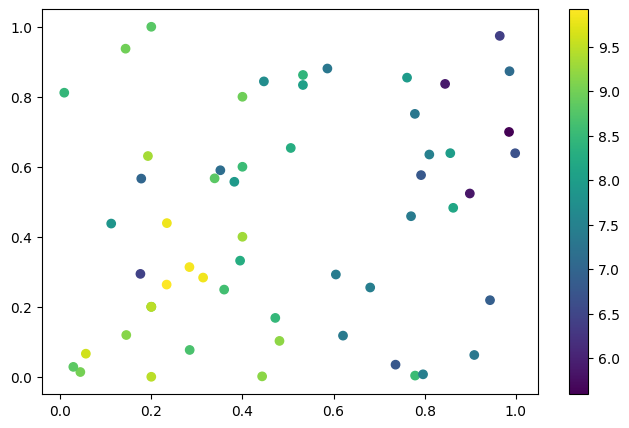

In [8]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

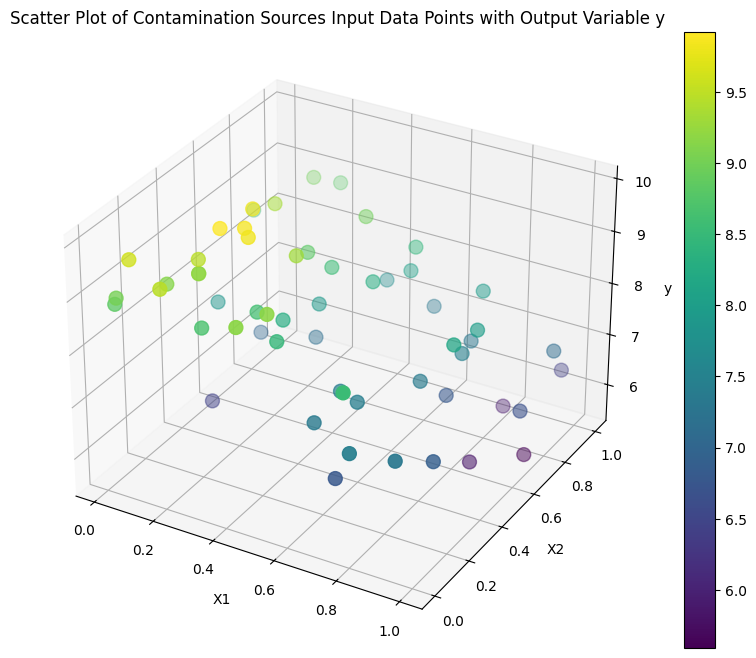

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [10]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [11]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 6)
    x2_grid = np.linspace(0.000001, 0.999999, 6)
    x3_grid = np.linspace(0.000001, 0.999999, 6)
    x4_grid = np.linspace(0.000001, 0.999999, 6)
    x5_grid = np.linspace(0.000001, 0.999999, 6)
    x6_grid = np.linspace(0.000001, 0.999999, 6)
    x7_grid = np.linspace(0.000001, 0.999999, 6)
    x8_grid = np.linspace(0.000001, 0.999999, 6)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(),  x4_grid.ravel(),  x5_grid.ravel(),  x6_grid.ravel(),  x7_grid.ravel(),  x8_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3, x4, x5, x6, x7, x8 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 6)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 6)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 6)
    x4_grid = np.linspace(max(0.000001, x4 - delta), min(0.999999, x4 + delta), 6)
    x5_grid = np.linspace(max(0.000001, x5 - delta), min(0.999999, x5 + delta), 6)
    x6_grid = np.linspace(max(0.000001, x6 - delta), min(0.999999, x6 + delta), 6)
    x7_grid = np.linspace(max(0.000001, x7 - delta), min(0.999999, x7 + delta), 6)
    x8_grid = np.linspace(max(0.000001, x8 - delta), min(0.999999, x8 + delta), 6)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel(), x5_grid.ravel(),  x6_grid.ravel(),  x7_grid.ravel(),  x8_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999),  # x3
        (0.000001, 0.999999),  # x4
        (0.000001, 0.999999),  # x5
        (0.000001, 0.999999),  # x6
        (0.000001, 0.999999),  # x7
        (0.000001, 0.999999)   # x8
    ]
    sampler = qmc.LatinHypercube(d=8)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta)),  # x3
        (max(0.000001, center[3] - delta), min(0.999999, center[3] + delta)),  # x4
        (max(0.000001, center[4] - delta), min(0.999999, center[4] + delta)),  # x5
        (max(0.000001, center[5] - delta), min(0.999999, center[5] + delta)),  # x6
        (max(0.000001, center[6] - delta), min(0.999999, center[6] + delta)),  # x7
        (max(0.000001, center[7] - delta), min(0.999999, center[7] + delta))   # x8
    ]
    sampler = qmc.LatinHypercube(d=8)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [12]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
       
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    next_query = next_query.reshape(1,8)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return next_query, y_pred

In [13]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

**Exploration**

Explore the whole space with **defalut** RBF Kernel

In [14]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.344834-0.044508


UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.200001-0.000001-0.600000-0.799999-0.200001-0.799999)
Predicted Value at (0.000001-0.200001-0.200001-0.000001-0.600000-0.799999-0.200001-0.799999) is 9.831449011590454)
Index of maximum acquisition function value:  288514


PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.400000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.400000) is 9.949928983902701)
Index of maximum acquisition function value:  336428


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.200001-0.200001-0.600000-0.999999-0.000001-0.799999)
Predicted Value at (0.000001-0.200001-0.200001-0.200001-0.600000-0.999999-0.000001-0.799999) is 9.533259344445167)
Index of maximum acquisition function value:  289840




**Exploitation**

In [15]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 9.9194021993664
Best query so far: [0.233694 0.263413 0.165382 0.26428  0.704578 0.543261 0.24493  0.382976]


In [16]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.968102-0.202079


UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.183694-0.213413-0.215382-0.214280-0.754578-0.593261-0.194930-0.432976)
Predicted Value at (0.183694-0.213413-0.215382-0.214280-0.754578-0.593261-0.194930-0.432976) is 9.923396561471375)
Index of maximum acquisition function value:  40145


PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.203694-0.273413-0.175382-0.214280-0.674578-0.553261-0.214930-0.392976)
Predicted Value at (0.203694-0.273413-0.175382-0.214280-0.674578-0.553261-0.214930-0.392976) is 9.941545924910928)
Index of maximum acquisition function value:  910125


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.283694-0.213413-0.215382-0.214280-0.754578-0.493261-0.194930-0.432976)
Predicted Value at (0.283694-0.213413-0.215382-0.214280-0.754578-0.493261-0.194930-0.432976) is 9.887681692550974)
Index of maximum acquisition function value:  273245


E

**Hyperparameter Tuning using gp_minimize**

In [17]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct
def query_black_box_function_with_hyper_parameters(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-10, 1e10))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-10, 1e10))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-10, 1e10))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    next_query = next_query.reshape(1, 8)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel Type:", kernel_type)

    return next_query, y_pred

**Hyperparameter Tuning using gp_minimize**

With Full Grid as Search Space

In [18]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x_grid = exploration_grid()


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the absolute value of the prediction as we want to get as close to zero as possible
    return np.abs(y_pred[0])

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.200001-0.200001-0.600000-0.999999-0.000001-0.799999)
Predicted Value at (0.000001-0.200001-0.200001-0.200001-0.600000-0.999999-0.000001-0.799999) is 9.533259344445167)
Index of maximum acquisition function value:  289840
Kernel Type: None


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.999999-0.600000-0.000001-0.999999)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.999999-0.600000-0.000001-0.999999) is 9.758079082080734)
Index of maximum acquisition function value:  282425
Kernel Type: RationalQuadratic


EI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.600000) is 9.973705562374573)
Index of maximum acquisition function value:  336429
Kernel Type: None


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.600000-0.000001-0.200001-0.999999-0.000001-0.000001-0.799999)
Predicted Value at (0.000001-0.600000-0.000001-0.200001-0.999999-0.000001-0.000001-0.799999) is 9.548606568609133)
Index of maximum acquisition function value:  8

...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.000001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.600000) is 9.971679511733743)
Index of maximum acquisition function value:  289773
Kernel Type: RationalQuadratic


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.000001-0.000001-0.600000-0.999999-0.200001-0.400000)
Predicted Value at (0.200001-0.200001-0.000001-0.000001-0.600000-0.999999-0.200001-0.400000) is 9.460797069824554)
Index of maximum acquisition function value:  327428
Kernel Type: None


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.400000-0.200001-0.600000-0.999999-0.000001-0.799999)
Predicted Value at (0.200001-0.200001-0.400000-0.200001-0.600000-0.999999-0.000001-0.799999) is 9.442838884006257)
Index of maximum acquisition funct

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.000001-0.799999-0.999999-0.999999-0.000001-0.200001)
Predicted Value at (0.200001-0.200001-0.000001-0.799999-0.999999-0.999999-0.000001-0.200001) is 9.653673737005974)
Index of maximum acquisition function value:  333037
Kernel Type: RationalQuadratic


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.400000-0.000001-0.200001-0.200001-0.600000-0.200001-0.200001-0.000001)
Predicted Value at (0.400000-0.000001-0.200001-0.200001-0.600000-0.200001-0.200001-0.000001) is 9.230865228110373)
Index of maximum acquisition function value:  103074
Kernel Type: None


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.400000-0.000001-0.999999-0.799999-0.000001-0.600000)
Predicted Value at (0.000001-0.000001-0.400000-0.000001-0.999999-0.799999-0.000001-0.600000) is 9.660072258875253)
Index of maximum acq

(array([[2.000006e-01, 2.000006e-01, 1.000000e-06, 2.000006e-01,
         5.999998e-01, 9.999990e-01, 1.000000e-06, 9.999990e-01]]),
 array([9.23117252]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **gp_minimize**

In [19]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.400000-0.000001-0.200001-0.000001-0.200001-0.600000-0.000001-0.799999)
Predicted Value at (0.400000-0.000001-0.200001-0.000001-0.200001-0.600000-0.000001-0.799999) is 9.243520300028669)
Index of maximum acquisition function value:  101416
Kernel Type: None


(array([[4.000002e-01, 1.000000e-06, 2.000006e-01, 1.000000e-06,
         2.000006e-01, 5.999998e-01, 1.000000e-06, 7.999994e-01]]),
 array([9.2435203]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **gp_minimize**

In [20]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 9.9194021993664
Best query so far: [0.233694 0.263413 0.165382 0.26428  0.704578 0.543261 0.24493  0.382976]


In [21]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.183694-0.313413-0.135382-0.274280-0.754578-0.593261-0.254930-0.412976)
Predicted Value at (0.183694-0.313413-0.135382-0.274280-0.754578-0.593261-0.254930-0.412976) is 9.89095502009172)
Index of maximum acquisition function value:  1412626
Kernel Type: None


(array([[0.183694, 0.313413, 0.135382, 0.27428 , 0.754578, 0.593261,
         0.25493 , 0.412976]]),
 array([9.89095502]))

**Hyperparameter Tuning with BayesianOptimization**

With Full Grid as Search Space

In [22]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

x_grid = exploration_grid()

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000) is 10.035531981193545)
Index of maximum acquisition function value:  281997
Kernel Type: RationalQuadratic
| 1         | -10.04    | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.400000-0.000001-0.400000-0.400000-0.600000-0.200001-0.600000)
Predicted Value at (0.000001-0.400000-0.000001-0.400000-0.400000-0.600000-0.200001-0.600000) is 9.949813819306986)
Index of maximum acquisition function value:  563013
Kernel Type: Matern
| 2         | -9.95     | 0.2323    | 2.732     | 2.404     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.400000-0.000001-0.400000-0.600000-0.600

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000) is 10.128201927465561)
Index of maximum acquisition function value:  281997
Kernel Type: RationalQuadratic
| 10        | -10.13    | 0.5367    | 2.618     | 2.936     | 0.3041    | 0.03139   | 14.07     |


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.600000-0.400000-0.799999-0.000001-0.400000)
Predicted Value at (0.000001-0.200001-0.000001-0.600000-0.400000-0.799999-0.000001-0.400000) is 9.708780529040041)
Index of maximum acquisition function value:  284402
Kernel Type: Matern
| 11        | -9.709    | 2.36      | 1.24      | 1.938     | 0.174     | 1e-10     | 5.32      |


EI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000) is 10.029612999964332)
Index of maximum acquisition function value:  281997
Kernel Type: RationalQuadratic
| 41        | -10.03    | 1.47      | 1.928     | 3.159     | 0.5649    | 0.01476   | 1.378     |


PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000) is 10.02625885979961)
Index of maximum acquisition function value:  328653
Kernel Type: Matern
| 42        | -10.03    | 0.6919    | 2.589     | 2.181     | 0.4199    | 0.02327   | 8.021     |


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.000001-0.200001-0.400000-0

(array([[1.000000e-06, 4.000002e-01, 1.000000e-06, 1.000000e-06,
         4.000002e-01, 9.999990e-01, 2.000006e-01, 4.000002e-01]]),
 array([9.34518252]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **BayesianOptimization**

In [23]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.400000-0.999999-0.000001-0.799999)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.400000-0.999999-0.000001-0.799999) is 9.565702327410833)
Index of maximum acquisition function value:  334984
Kernel Type: None


(array([[2.000006e-01, 2.000006e-01, 2.000006e-01, 1.000000e-06,
         4.000002e-01, 9.999990e-01, 1.000000e-06, 7.999994e-01]]),
 array([9.56570233]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization**

In [24]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 9.9194021993664
Best query so far: [0.233694 0.263413 0.165382 0.26428  0.704578 0.543261 0.24493  0.382976]


In [25]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.183694-0.253413-0.135382-0.314280-0.674578-0.593261-0.194930-0.432976)
Predicted Value at (0.183694-0.253413-0.135382-0.314280-0.674578-0.593261-0.194930-0.432976) is 9.910478904333338)
Index of maximum acquisition function value:  574529
Kernel Type: None


(array([[0.183694, 0.253413, 0.135382, 0.31428 , 0.674578, 0.593261,
         0.19493 , 0.432976]]),
 array([9.9104789]))

**Hyperparameter Tuning using BayesianOptimization]**

Latin Hypercube Sampling

In [26]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

lhs_samples = exploration_latin_hypercube()

# Define the function to optimize
def objective_function_bo_lhs(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, lhs_samples,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo_lhs,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, lhs_samples,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.140401-0.416003-0.182571-0.302919-0.669369-0.603830-0.223201-0.444812)
Predicted Value at (0.140401-0.416003-0.182571-0.302919-0.669369-0.603830-0.223201-0.444812) is 9.958864273056525)
Index of maximum acquisition function value:  4928
Kernel Type: RationalQuadratic
| 1         | -9.959    | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.077734-0.154127-0.046451-0.447748-0.351491-0.415268-0.162019-0.641397)
Predicted Value at (0.077734-0.154127-0.046451-0.447748-0.351491-0.415268-0.162019-0.641397) is 9.890925651525752)
Index of maximum acquisition function value:  8081
Kernel Type: Matern
| 2         | -9.891    | 0.2323    | 2.732     | 2.404     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.085448-0.267600-0.015997-0.504349-0.641054-0.277518-0.10802

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.173482-0.371574-0.058326-0.201767-0.847500-0.616858-0.280254-0.634978)
Predicted Value at (0.173482-0.371574-0.058326-0.201767-0.847500-0.616858-0.280254-0.634978) is 9.922557300595736)
Index of maximum acquisition function value:  898
Kernel Type: RationalQuadratic
| 45        | -9.923    | 3.309     | 1.445     | 3.359     | 0.3918    | 0.004861  | 14.57     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.168759-0.327617-0.031435-0.372414-0.495318-0.277992-0.262458-0.436068)
Predicted Value at (0.168759-0.327617-0.031435-0.372414-0.495318-0.277992-0.262458-0.436068) is 10.010180869763396)
Index of maximum acquisition function value:  5822
Kernel Type: Matern
| 46        | -10.01    | 0.5053    | 1.465     | 1.876     | 0.5351    | 0.03322   | 11.13     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.168759-0.327617-0.031435-0.372414-0.495318-0.277992-0.262458

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.085448-0.267600-0.015997-0.504349-0.641054-0.277518-0.108027-0.483348)
Predicted Value at (0.085448-0.267600-0.015997-0.504349-0.641054-0.277518-0.108027-0.483348) is 10.232941213317293)
Index of maximum acquisition function value:  4927
Kernel Type: RationalQuadratic
| 54        | -10.23    | 0.6366    | 2.808     | 3.237     | 0.03856   | 0.0979    | 1.859     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.008782-0.059225-0.047736-0.432025-0.877831-0.116131-0.055251-0.594796)
Predicted Value at (0.008782-0.059225-0.047736-0.432025-0.877831-0.116131-0.055251-0.594796) is 10.9595395574739)
Index of maximum acquisition function value:  9840
Kernel Type: DotProduct
| 55        | -10.96    | 1.909     | 2.21      | 3.719     | 0.91      | 0.07368   | 3.415     |
Best Parameters: rbf_lengthscale=0.01, noise_assumption=1e-10, restarts=4, beta=1.0, kernel_type=RationalQ

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[0.35646466, 0.28807696, 0.12781666, 0.17664499, 0.76908306,
         0.53467751, 0.36039063, 0.47314691]]),
 array([0.26506436]))

**Exploration**

Explore the Latin Hypescale search space with Best Hyperparameters found using **BaysianOptimization on Latin Hypescale Search Space**

In [27]:

next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_latin_hypercube(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.003022-0.019377-0.143507-0.053868-0.880448-0.428685-0.162705-0.839767)
Predicted Value at (0.003022-0.019377-0.143507-0.053868-0.880448-0.428685-0.162705-0.839767) is 9.87892302468911)
Index of maximum acquisition function value:  5148
Kernel Type: RationalQuadratic


(array([[0.00302164, 0.01937731, 0.14350653, 0.0538675 , 0.88044782,
         0.42868458, 0.16270467, 0.83976741]]),
 array([9.87892302]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization on Latin Hypescale Search Space**

In [28]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 9.9194021993664
Best query so far: [0.233694 0.263413 0.165382 0.26428  0.704578 0.543261 0.24493  0.382976]


In [29]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_latin_hypercube(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.255812-0.288435-0.156185-0.276366-0.698576-0.535932-0.254901-0.393265)
Predicted Value at (0.255812-0.288435-0.156185-0.276366-0.698576-0.535932-0.254901-0.393265) is 9.782299850609586)
Index of maximum acquisition function value:  4323
Kernel Type: RationalQuadratic


(array([[0.25581212, 0.288435  , 0.15618451, 0.27636594, 0.69857641,
         0.5359324 , 0.25490122, 0.39326529]]),
 array([9.78229985]))